In [1]:
import numpy as np
from sklearn.preprocessing import StandardScaler

full = np.load("./data/processed/dataset_full.npz", allow_pickle=True)
X = full["X"]
K0 = full["K0"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [2]:
from sklearn.decomposition import PCA

pca = PCA(n_components=5)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance:", pca.explained_variance_ratio_)


Explained variance: [0.39842863 0.13040844 0.12491463 0.12491463 0.05794302]


In [3]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, random_state=0)
labels = kmeans.fit_predict(X_pca)


<Axes: title={'center': 'KMeans cluster fractions vs K0'}, xlabel='K0'>

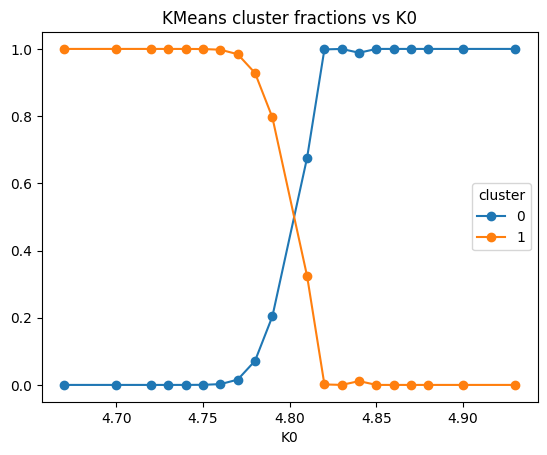

In [4]:
import pandas as pd

df = pd.DataFrame({
    "K0": K0,
    "cluster": labels
})

cluster_fraction = (
    df.groupby("K0")["cluster"]
      .value_counts(normalize=True)
      .unstack(fill_value=0)
)

cluster_fraction.plot(marker="o", title="KMeans cluster fractions vs K0")


In [5]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=2, random_state=0)
gmm.fit(X_pca)

labels = gmm.predict(X_pca)
probs = gmm.predict_proba(X_pca)


<Axes: title={'center': 'GMM susceptibility'}, xlabel='K0'>

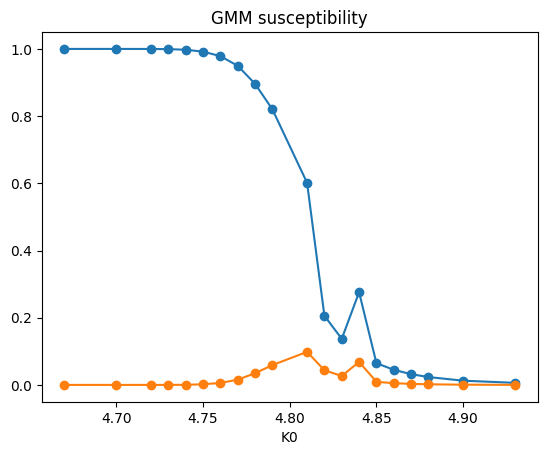

In [6]:
df = pd.DataFrame({
    "K0": K0,
    "P_cluster1": probs[:, 1]
})

mean_P = df.groupby("K0").mean()["P_cluster1"]
var_P  = df.groupby("K0").var()["P_cluster1"]

mean_P.plot(marker="o", title="GMM mean cluster probability")
var_P.plot(marker="o", title="GMM susceptibility")


In [7]:
from sklearn.cluster import AgglomerativeClustering

X_pca_thin = X_pca[::5000]
K0_thin = K0[::5000]
agg = AgglomerativeClustering(n_clusters=2, linkage="ward")
labels = agg.fit_predict(X_pca_thin)


<Axes: title={'center': 'Agglomerative (thinned) cluster fractions vs K0'}, xlabel='K0'>

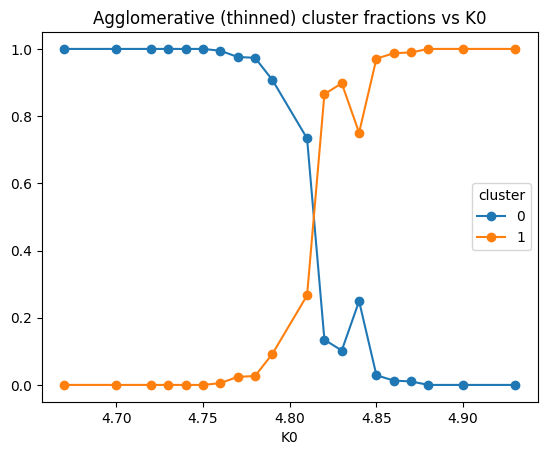

In [8]:
import pandas as pd

df = pd.DataFrame({
    "K0": K0_thin,
    "cluster": labels
})

cluster_fraction = (
    df.groupby("K0")["cluster"]
      .value_counts(normalize=True)
      .unstack(fill_value=0)
)

cluster_fraction.plot(marker="o", title="Agglomerative (thinned) cluster fractions vs K0")
